# CGMacros Dataset Analysis

**Experiment:** exploratory data analysis (EDA) of the CGMacros dataset, laying the groundwork for the preprocessing and feature-engineering pipeline used elsewhere in this project.

## Why CGMacros and not OhioT1DM?

The most widely used public benchmark for CGM-based glucose forecasting is the **OhioT1DM** dataset (Marling & Bunescu, 2020), which provides eight weeks of CGM, insulin, and self-reported life-event data for 12 people with type 1 diabetes. However, OhioT1DM records meals only as self-reported carbohydrate estimates and does **not** include any photographic record of food intake.

Since the central contribution of this dissertation is a multimodal architecture that fuses CGM history with visual food information, OhioT1DM cannot support the modality this work depends on. **CGMacros** (Das et al., 2025) is, to the best of our knowledge, the only public CGM dataset that pairs continuous glucose traces with timestamped food photographs of the actual logged meals rather than food-database lookups alone -- so it is the dataset used throughout this dissertation.

## 0. Setup (Colab / local)

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # NOTE: adjust this to wherever CGMacros/ and bio.csv actually live in Drive
    DATA_ROOT = '/content/drive/MyDrive/dissertation_data'
else:
    DATA_ROOT = '.'  # CGMacros/ and bio.csv expected alongside this notebook (local symlinks)

print(f"IN_COLAB={IN_COLAB}  DATA_ROOT={DATA_ROOT}")

In [ ]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
COLORS = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']

## 1. Cohort Overview

CGMacros is a 10-day free-living observational study of participants stratified by baseline HbA1c into three glycemic groups. Each participant wore a Dexcom G6 Pro CGM (5-minute native sampling) and an Abbott FreeStyle Libre Pro CGM (15-minute native sampling) concurrently, alongside a Fitbit smartwatch. Every logged meal includes a timestamp, macronutrient breakdown, and (for the large majority of meals) a smartphone photograph.

In [2]:
bio = pd.read_csv(os.path.join(DATA_ROOT, 'bio.csv'))
bio.columns = [c.strip() for c in bio.columns]
a1c = bio['A1c PDL (Lab)'].astype(float)

def hba1c_group(x):
    if x < 5.7:
        return 'Healthy'
    elif x < 6.5:
        return 'Prediabetes'
    return 'Type 2 Diabetes'

bio['group'] = a1c.apply(hba1c_group)

print(f"N participants: {len(bio)}")
print(bio['group'].value_counts().reindex(['Healthy', 'Prediabetes', 'Type 2 Diabetes']))
print()
print(f"Age (years):      mean={bio.Age.mean():.1f}  std={bio.Age.std():.1f}  range=[{bio.Age.min()}, {bio.Age.max()}]")
print(f"Sex:              {(bio.Gender=='F').sum()} female / {(bio.Gender=='M').sum()} male")
print(f"BMI (kg/m^2):     mean={bio.BMI.mean():.1f}  std={bio.BMI.std():.1f}")
print(f"HbA1c (%):        mean={a1c.mean():.2f}  std={a1c.std():.2f}  range=[{a1c.min():.1f}, {a1c.max():.1f}]")
print()
print('Race/ethnicity:')
print(bio['Self-identify'].value_counts())

N participants: 45
group
Healthy            15
Prediabetes        16
Type 2 Diabetes    14
Name: count, dtype: int64

Age (years):      mean=48.1  std=12.7  range=[18, 69]
Sex:              29 female / 16 male
BMI (kg/m^2):     mean=31.1  std=6.7
HbA1c (%):        mean=6.12  std=0.91  range=[4.6, 8.5]

Race/ethnicity:
Self-identify
Hispanic/Latino            34
White                       7
African American            3
Black, African American     1
Name: count, dtype: int64


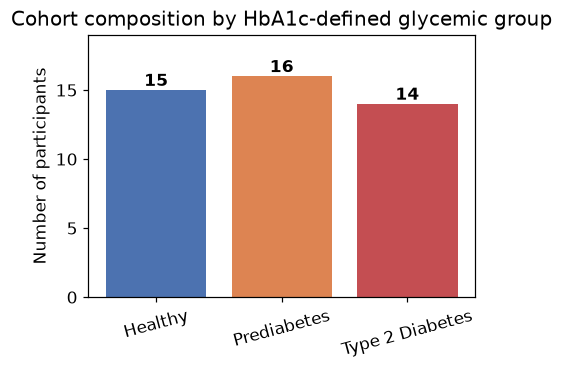

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
counts = bio['group'].value_counts().reindex(['Healthy', 'Prediabetes', 'Type 2 Diabetes'])
ax.bar(counts.index, counts.values, color=COLORS[:3])
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
ax.set_ylabel('Number of participants')
ax.set_title('Cohort composition by HbA1c-defined glycemic group')
ax.set_ylim(0, max(counts.values) + 3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Group boundaries follow the standard ADA HbA1c thresholds (healthy: <5.7%, prediabetes: 5.7-6.4%, type 2 diabetes: >=6.5%). Recomputing the split from the raw HbA1c values reproduces the group sizes reported by the original CGMacros authors (15 healthy / 16 prediabetes / 14 type 2) **exactly**, confirming this labeling convention is correct.

## 2. Loading the CGM Traces

Each participant's CSV is already pre-aligned onto a common 1-minute timeline by the dataset authors -- the raw 5-minute Dexcom and 15-minute Libre readings are interpolated onto this grid before release, so any residual missingness in the Dexcom column reflects genuine sensor dropout rather than the native sampling interval.

The two CGM devices are known to disagree systematically (Das et al., 2025 report statistically significant differences between them across all three participant groups, plausibly due to sensor placement / subcutaneous fat). To avoid mixing two sensors with different accuracy characteristics, this dissertation uses the **Dexcom G6 channel exclusively** -- it has the higher native sampling rate of the two, and is the CGM most commonly reported against elsewhere in the forecasting literature.

In [4]:
files = sorted(glob.glob(os.path.join(DATA_ROOT, 'CGMacros', 'CGMacros-*', 'CGMacros-*.csv')))
subj_group = dict(zip(bio['subject'].astype(int), bio['group']))

all_glucose = []
glucose_by_group = {'Healthy': [], 'Prediabetes': [], 'Type 2 Diabetes': []}
missing_frac, durations = [], []
meal_rows_total, meal_rows_with_photo = 0, 0
photo_counts = []
carbs_all = []

for f in files:
    sid = int(os.path.basename(f).split('-')[1].split('.')[0])
    df = pd.read_csv(f)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    dex = df['Dexcom GL']
    missing_frac.append(dex.isna().mean())
    durations.append((df['Timestamp'].max() - df['Timestamp'].min()).total_seconds() / 86400)

    vals = dex.dropna().values
    all_glucose.append(vals)
    g = subj_group.get(sid)
    if g is not None:
        glucose_by_group[g].append(vals)

    meals = df[df['Meal Type'].notna()]
    meal_rows_total += len(meals)
    meal_rows_with_photo += meals['Image path'].notna().sum()
    carbs_all.append(df['Carbs'].dropna())

    pdir = os.path.join(os.path.dirname(f), 'photos')
    photo_counts.append(
        len([x for x in os.listdir(pdir) if x.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if os.path.isdir(pdir) else 0
    )

all_glucose = np.concatenate(all_glucose)
carbs_all = pd.concat(carbs_all)
print(f"Loaded {len(files)} participant CSVs, {len(all_glucose):,} valid Dexcom readings total.")

Loaded 45 participant CSVs, 629,825 valid Dexcom readings total.


The nominal study protocol specifies a 10-day monitoring window, but the actual recorded span per participant varies. This is a data-quality consideration carried forward into the preprocessing design, since it means the train/validation/test split cannot assume a uniform number of samples per participant.

In [5]:
print(f"Recorded monitoring span (days): mean={np.mean(durations):.2f}  "
      f"range=[{np.min(durations):.2f}, {np.max(durations):.2f}]")

Recorded monitoring span (days): mean=10.90  range=[7.23, 19.15]


## 3. Glucose Distribution

In [6]:
print(f"Dexcom glucose: N={len(all_glucose):,}  mean={all_glucose.mean():.1f}  "
      f"std={all_glucose.std():.1f}  range=[{all_glucose.min():.0f}, {all_glucose.max():.0f}] mg/dL")

hypo = (all_glucose < 70).mean() * 100
eug = ((all_glucose >= 70) & (all_glucose <= 180)).mean() * 100
hyper = (all_glucose > 180).mean() * 100
print(f"Time-in-range:  hypoglycemia (<70) = {hypo:.2f}%   "
      f"euglycemia (70-180) = {eug:.2f}%   hyperglycemia (>180) = {hyper:.2f}%")

Dexcom glucose: N=629,825  mean=140.9  std=42.0  range=[40, 400] mg/dL
Time-in-range:  hypoglycemia (<70) = 0.37%   euglycemia (70-180) = 85.30%   hyperglycemia (>180) = 14.33%


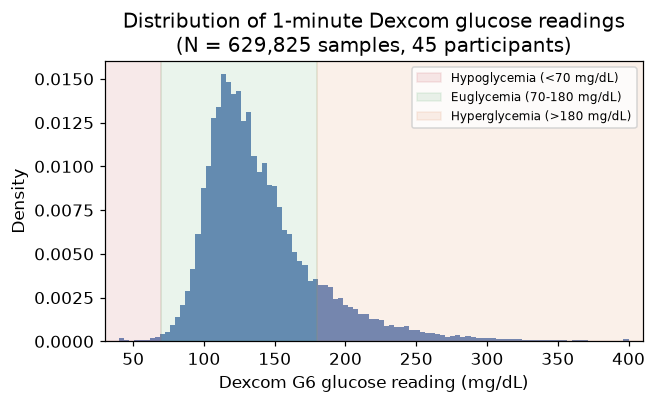

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.hist(all_glucose, bins=100, color=COLORS[0], alpha=0.85, density=True)
ax.axvspan(0, 70, color=COLORS[2], alpha=0.12, label='Hypoglycemia (<70 mg/dL)')
ax.axvspan(70, 180, color=COLORS[3], alpha=0.12, label='Euglycemia (70-180 mg/dL)')
ax.axvspan(180, 420, color=COLORS[1], alpha=0.12, label='Hyperglycemia (>180 mg/dL)')
ax.set_xlim(30, 410)
ax.set_xlabel('Dexcom G6 glucose reading (mg/dL)')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of 1-minute Dexcom glucose readings\n(N = {len(all_glucose):,} samples, {len(files)} participants)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

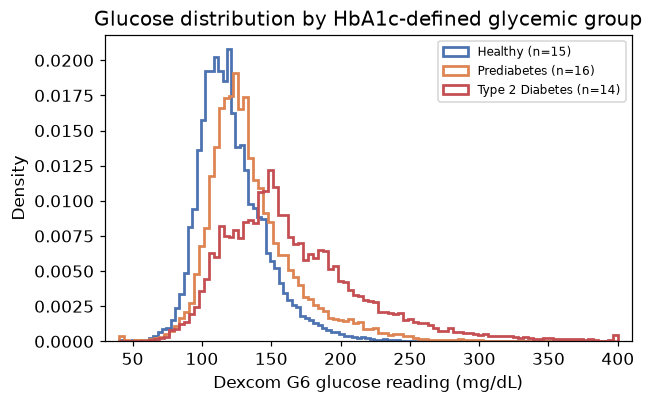

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.8))
for g, c in zip(['Healthy', 'Prediabetes', 'Type 2 Diabetes'], COLORS[:3]):
    vals = np.concatenate(glucose_by_group[g])
    ax.hist(vals, bins=100, density=True, histtype='step', linewidth=1.8, color=c,
            label=f'{g} (n={len(glucose_by_group[g])})')
ax.set_xlim(30, 410)
ax.set_xlabel('Dexcom G6 glucose reading (mg/dL)')
ax.set_ylabel('Density')
ax.set_title('Glucose distribution by HbA1c-defined glycemic group')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

The overall distribution is right-skewed with a long hyperglycemic tail, and is clipped at the Dexcom G6's reportable range of 40-400 mg/dL. As expected, the type 2 diabetes group is shifted markedly right with the heaviest hyperglycemic tail, while the healthy group is concentrated tightly within the euglycemic band.

Because hypoglycemic (and, to a lesser extent, severely hyperglycemic) samples are a small minority of the overall test distribution, an aggregate metric such as overall RMSE is dominated by the easy euglycemic majority -- this is precisely the motivation for also reporting the glycemic-range-stratified **gRMSE** metric used in the evaluation methodology.

## 4. Sensor Missingness

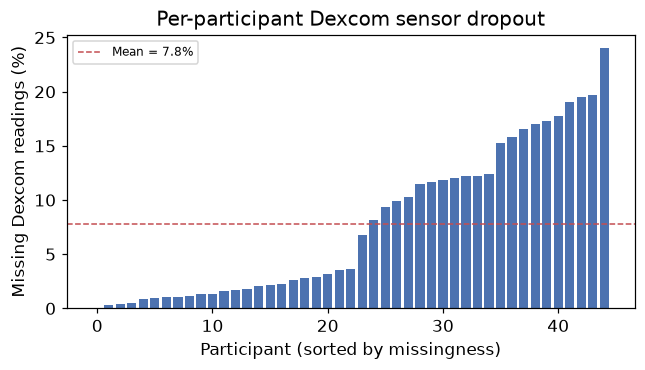

Missingness: mean=7.8%  range=[0.0%, 24.0%]


In [9]:
fig, ax = plt.subplots(figsize=(6, 3.5))
order = np.argsort(missing_frac)
ax.bar(range(len(missing_frac)), 100 * np.array(missing_frac)[order], color=COLORS[0])
ax.set_xlabel('Participant (sorted by missingness)')
ax.set_ylabel('Missing Dexcom readings (%)')
ax.set_title('Per-participant Dexcom sensor dropout')
mean_missing = 100 * np.mean(missing_frac)
ax.axhline(mean_missing, color=COLORS[2], linestyle='--', linewidth=1, label=f'Mean = {mean_missing:.1f}%')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Missingness: mean={mean_missing:.1f}%  range=[{100*np.min(missing_frac):.1f}%, {100*np.max(missing_frac):.1f}%]")

Missingness is highly uneven across participants, reflecting sensor dropout, warm-up periods, and occasional sensor replacement rather than a uniform data-collection artifact. This per-participant variability motivates a **gap-limited linear interpolation** strategy (bounded to a maximum contiguous gap, e.g. 15 minutes) during preprocessing, rather than a uniform imputation rule applied indiscriminately across the whole cohort.

## 5. Meal and Food-Photo Coverage

In [10]:
photo_coverage = 100 * meal_rows_with_photo / meal_rows_total
print(f"Logged meal events:          {meal_rows_total:,}")
print(f"Meals with a food photo:     {meal_rows_with_photo:,} ({photo_coverage:.1f}%)")
print(f"Total photos collected:      {sum(photo_counts):,} "
      f"(mean={np.mean(photo_counts):.1f}/participant, range=[{np.min(photo_counts)}, {np.max(photo_counts)}])")
print()
print(f"Logged carbohydrates (g):    mean={carbs_all.mean():.1f}  std={carbs_all.std():.1f}  "
      f"max={carbs_all.max():.0f}")
print(f"  -> top 5 largest logged values: {sorted(carbs_all.values)[-5:]}")

Logged meal events:          1,706
Meals with a food photo:     1,644 (96.4%)
Total photos collected:      3,449 (mean=76.6/participant, range=[40, 126])

Logged carbohydrates (g):    mean=52.1  std=40.1  max=761
  -> top 5 largest logged values: [np.float64(276.0), np.float64(282.0), np.float64(382.0), np.float64(472.0), np.float64(761.0)]


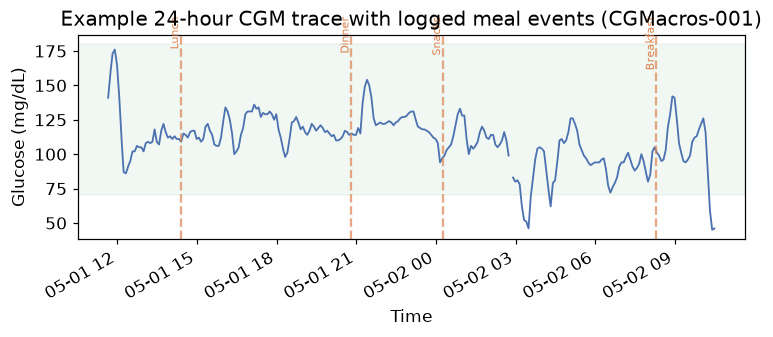

In [11]:
sample_df = pd.read_csv(files[0])
sample_df['Timestamp'] = pd.to_datetime(sample_df['Timestamp'])
day1 = sample_df[(sample_df['Timestamp'] >= sample_df['Timestamp'].min()) &
                  (sample_df['Timestamp'] < sample_df['Timestamp'].min() + pd.Timedelta(days=1))]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(day1['Timestamp'], day1['Dexcom GL'], color=COLORS[0], linewidth=1.2)
meals = day1[day1['Meal Type'].notna()]
for _, row in meals.iterrows():
    ax.axvline(row['Timestamp'], color=COLORS[1], linestyle='--', alpha=0.7)
    ax.text(row['Timestamp'], 200, row['Meal Type'], rotation=90, fontsize=7,
            va='top', ha='right', color=COLORS[1])
ax.axhspan(70, 180, color=COLORS[3], alpha=0.08)
ax.set_xlabel('Time')
ax.set_ylabel('Glucose (mg/dL)')
ax.set_title(f'Example 24-hour CGM trace with logged meal events ({os.path.basename(files[0]).replace(".csv", "")})')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Photo coverage of logged meals is high (>96%) but not complete, so downstream models must treat the image modality as **optionally present** via an explicit `has_image` gate rather than assuming every sample carries a visual input. Logged carbohydrate content contains a small number of extreme outliers that are almost certainly logging errors rather than genuine intake -- flagged here as a concrete data-cleaning target for the preprocessing stage.

## 6. Summary

This EDA establishes four properties of CGMacros that directly shape the preprocessing and feature-engineering pipeline:

1. **Glycemic imbalance.** The cohort is glycemically heterogeneous but numerically dominated by euglycemic samples, motivating range-stratified evaluation (gRMSE) in addition to aggregate metrics (RMSE/MAE/MAPE).
2. **Uneven coverage.** Per-participant recording span and sensor missingness are both uneven, ruling out preprocessing strategies that assume uniform per-participant coverage.
3. **Partial image coverage.** Food-photo coverage of logged meals is high (96.4%) but not complete, requiring an explicit `has_image` gating mechanism.
4. **Noisy macronutrient logs.** Manual meal logging contains outliers consistent with entry error, requiring basic sanity-bound filtering prior to model training.

-> Next experiment: `preprocessing/` (windowing, interpolation, image-meal matching, train/val/test split).

## References

- Das, A., Kerr, D., Glantz, N., Bevier, W., Santiago, R., Gutierrez-Osuna, R., & Mortazavi, B. J. (2025). CGMacros: a pilot scientific dataset for personalized nutrition and diet monitoring. *Scientific Data*, 12, 1557. https://doi.org/10.1038/s41597-025-05851-7
- Marling, C., & Bunescu, R. C. (2020). The OhioT1DM Dataset for Blood Glucose Level Prediction: Update 2020. In *Proceedings of the 5th International Workshop on Knowledge Discovery in Healthcare Data (KDH@ECAI 2020)*, CEUR Workshop Proceedings, 2675, 71-74.